In [51]:
import re
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [52]:
torch.__version__

'2.13.0+cpu'

In [53]:
corpus = """
I love natural language processing.
I love machine learning.
I love deep learning.
Machine learning is a branch of artificial intelligence.
Deep learning is a branch of machine learning.
Natural language processing is an important field of artificial intelligence.
Word embeddings represent words as vectors.
Word2Vec learns meaningful word representations.
Machine learning uses data to learn patterns.
Deep learning uses neural networks to learn patterns.
"""

In [54]:
def tokenizer(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.split()

tokens = tokenizer(corpus)
tokens[:5]

['i', 'love', 'natural', 'language', 'processing']

In [55]:
len(tokens)

65

In [56]:
word_counts = Counter(tokens)
word_counts

Counter({'learning': 7,
         'machine': 4,
         'i': 3,
         'love': 3,
         'deep': 3,
         'is': 3,
         'of': 3,
         'natural': 2,
         'language': 2,
         'processing': 2,
         'a': 2,
         'branch': 2,
         'artificial': 2,
         'intelligence': 2,
         'word': 2,
         'uses': 2,
         'to': 2,
         'learn': 2,
         'patterns': 2,
         'an': 1,
         'important': 1,
         'field': 1,
         'embeddings': 1,
         'represent': 1,
         'words': 1,
         'as': 1,
         'vectors': 1,
         'wordvec': 1,
         'learns': 1,
         'meaningful': 1,
         'representations': 1,
         'data': 1,
         'neural': 1,
         'networks': 1})

In [57]:
vocab = sorted(word_counts.keys())
vocab


['a',
 'an',
 'artificial',
 'as',
 'branch',
 'data',
 'deep',
 'embeddings',
 'field',
 'i',
 'important',
 'intelligence',
 'is',
 'language',
 'learn',
 'learning',
 'learns',
 'love',
 'machine',
 'meaningful',
 'natural',
 'networks',
 'neural',
 'of',
 'patterns',
 'processing',
 'represent',
 'representations',
 'to',
 'uses',
 'vectors',
 'word',
 'words',
 'wordvec']

In [58]:
word_to_id = {idx: word for word , idx in enumerate(vocab)}
word_to_id


{'a': 0,
 'an': 1,
 'artificial': 2,
 'as': 3,
 'branch': 4,
 'data': 5,
 'deep': 6,
 'embeddings': 7,
 'field': 8,
 'i': 9,
 'important': 10,
 'intelligence': 11,
 'is': 12,
 'language': 13,
 'learn': 14,
 'learning': 15,
 'learns': 16,
 'love': 17,
 'machine': 18,
 'meaningful': 19,
 'natural': 20,
 'networks': 21,
 'neural': 22,
 'of': 23,
 'patterns': 24,
 'processing': 25,
 'represent': 26,
 'representations': 27,
 'to': 28,
 'uses': 29,
 'vectors': 30,
 'word': 31,
 'words': 32,
 'wordvec': 33}

In [59]:
id_to_word = {idx: word for word, idx in word_to_id.items()}
id_to_word

{0: 'a',
 1: 'an',
 2: 'artificial',
 3: 'as',
 4: 'branch',
 5: 'data',
 6: 'deep',
 7: 'embeddings',
 8: 'field',
 9: 'i',
 10: 'important',
 11: 'intelligence',
 12: 'is',
 13: 'language',
 14: 'learn',
 15: 'learning',
 16: 'learns',
 17: 'love',
 18: 'machine',
 19: 'meaningful',
 20: 'natural',
 21: 'networks',
 22: 'neural',
 23: 'of',
 24: 'patterns',
 25: 'processing',
 26: 'represent',
 27: 'representations',
 28: 'to',
 29: 'uses',
 30: 'vectors',
 31: 'word',
 32: 'words',
 33: 'wordvec'}

In [60]:
vocab_size = len(vocab)
vocab_size

34

In [61]:
encoded_tokens = [word_to_id[word] for word in tokens]
encoded_tokens[:7]

[9, 17, 20, 13, 25, 9, 17]

In [62]:
tokens[6]

'love'

In [63]:
window_size = 2
def create_cbow_pairs(tokens, window_size=2):
    pairs = []

    for i in range(len(tokens)):
        traget = tokens[i]

        start = max(0, i - window_size)
        end = min(len(tokens), i + window_size + 1)

        context = []

        for j in range(start, end):
            if j != i:
                context.append(tokens[j])

        pairs.append((context, traget))

    return pairs

        


pairs = create_cbow_pairs(encoded_tokens, window_size=2)
pairs[:10]

[([17, 20], 9),
 ([9, 20, 13], 17),
 ([9, 17, 13, 25], 20),
 ([17, 20, 25, 9], 13),
 ([20, 13, 9, 17], 25),
 ([13, 25, 17, 18], 9),
 ([25, 9, 18, 15], 17),
 ([9, 17, 15, 9], 18),
 ([17, 18, 9, 17], 15),
 ([18, 15, 17, 6], 9)]

In [64]:
for context, traget in pairs[:10]:
    context_words = [id_to_word[idx] for idx in context]
    traget_word = id_to_word[traget]
    print(context_words, '-->', traget_word)

['love', 'natural'] --> i
['i', 'natural', 'language'] --> love
['i', 'love', 'language', 'processing'] --> natural
['love', 'natural', 'processing', 'i'] --> language
['natural', 'language', 'i', 'love'] --> processing
['language', 'processing', 'love', 'machine'] --> i
['processing', 'i', 'machine', 'learning'] --> love
['i', 'love', 'learning', 'i'] --> machine
['love', 'machine', 'i', 'love'] --> learning
['machine', 'learning', 'love', 'deep'] --> i


In [65]:
class CBOWDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        context, traget = self.pairs[idx]
        context = torch.tensor(context, dtype = torch.long)
        traget = torch.tensor(traget, dtype=torch.long)
        return context, traget

In [66]:
dataset = CBOWDataset(pairs)
dataset

In [67]:
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
dataloader

In [68]:
len(dataloader)

65

In [69]:
class CBOW(nn.Module):

    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context):
        embeddings = self.embedding(context)
        hidden = embeddings.mean(dim=1)
        output = self.linear(hidden)
        return output

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [71]:
embedding_dim = 16

model = CBOW(vocab_size=vocab_size, embedding_dim=embedding_dim).to(device)
model

CBOW(
  (embedding): Embedding(34, 16)
  (linear): Linear(in_features=16, out_features=34, bias=True)
)

In [72]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [73]:
epochs = 100
loss_history = []

for epoch in range(epochs):
    total_loss = 0

    for context, traget in dataloader:

        context = context.to(device)
        traget = traget.to(device)

        optimizer.zero_grad()

        output = model(context)
        loss = criterion(output, traget)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = (total_loss/len(dataloader))
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 ==0:
        print(f'epoch {epoch}--> loss {avg_loss}')

epoch 9--> loss 1.4772075721850761
epoch 19--> loss 0.5196398333288156
epoch 29--> loss 0.2603012182105046
epoch 39--> loss 0.15940575169829221
epoch 49--> loss 0.1177396434180152
epoch 59--> loss 0.0853827655995981
epoch 69--> loss 0.0847202124253202
epoch 79--> loss 0.07367734931489954
epoch 89--> loss 0.060891259172841765
epoch 99--> loss 0.06653286182129076


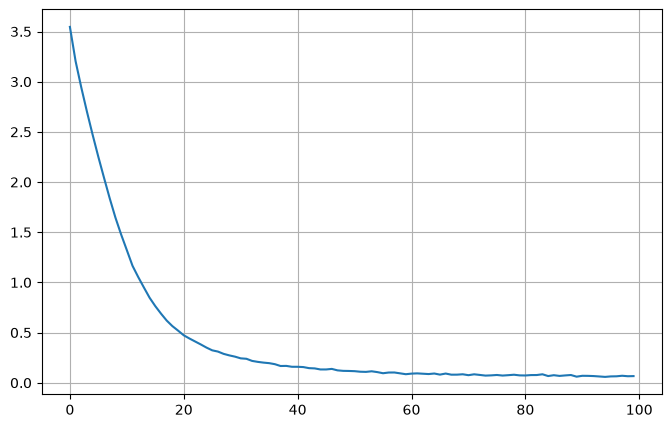

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.grid()



In [75]:
model.embedding.weight.shape

torch.Size([34, 16])

In [76]:
embedding = model.embedding.weight.detach().cpu()
embedding.shape

torch.Size([34, 16])

In [77]:
def get_embedding(word):

    idx = word_to_id[word]
    return embedding[idx]

In [78]:
word = 'machine'
vector = get_embedding(word)

In [79]:
vector

tensor([ 0.1103, -3.0736, -3.5926, -1.9027,  2.7799, -1.9020,  0.7699,  0.5128,
        -0.9790,  1.8986,  0.1018,  1.1104, -2.8066,  1.9047,  0.6026,  1.5233])

In [80]:
vector.shape

torch.Size([16])

In [81]:
import torch.nn.functional as F

def similarity(word1, word2):

    vec1 = get_embedding(word1)
    vec2 = get_embedding(word2)

    score = F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0))

    return score.item()

In [82]:
similarity('machine','learning')

-0.2026543766260147

In [83]:
similarity('data','deep')

0.3297324478626251

In [88]:
def most_similar(
    word,
    top_k=5
):

    word_idx = word_to_id[word]

    query_vector = embedding[word_idx]

    similarities = F.cosine_similarity(
        query_vector.unsqueeze(0),
        embedding
    )

    values, indices = torch.topk(
        similarities,
        k=min(
            top_k + 1,
            vocab_size
        )
    )

    results = []

    for value, idx in zip(
        values,
        indices
    ):

        idx = idx.item()

        if idx != word_idx:

            results.append(
                (
                    id_to_word[idx],
                    value.item()
                )
            )

    return results[:top_k]



In [89]:
word = "machine"

results = most_similar(
    word,
    top_k=5
)

print(
    f"Words similar to '{word}':"
)

for word, score in results:

    print(
        f"{word:15s} {score:.4f}"
    )

Words similar to 'machine':
neural          0.6451
a               0.5520
love            0.4249
uses            0.4228
intelligence    0.4183


In [93]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

embeddings_2d = pca.fit_transform(
    embedding.numpy()
)

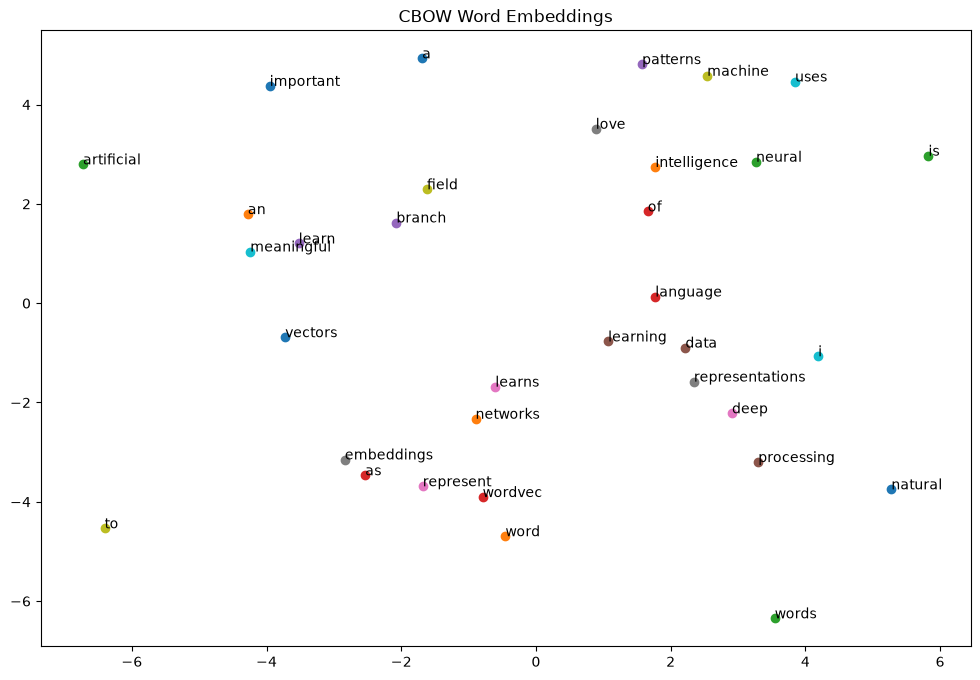

In [94]:
plt.figure(figsize=(12, 8))

for idx, word in id_to_word.items():

    x = embeddings_2d[idx, 0]
    y = embeddings_2d[idx, 1]

    plt.scatter(x, y)

    plt.annotate(
        word,
        (x, y),
        fontsize=10
    )

plt.title(
    "CBOW Word Embeddings"
)

plt.show()